# The Cropland Data Layer
### Exploring US Crop Production


### The Corn and Soybean Rotation

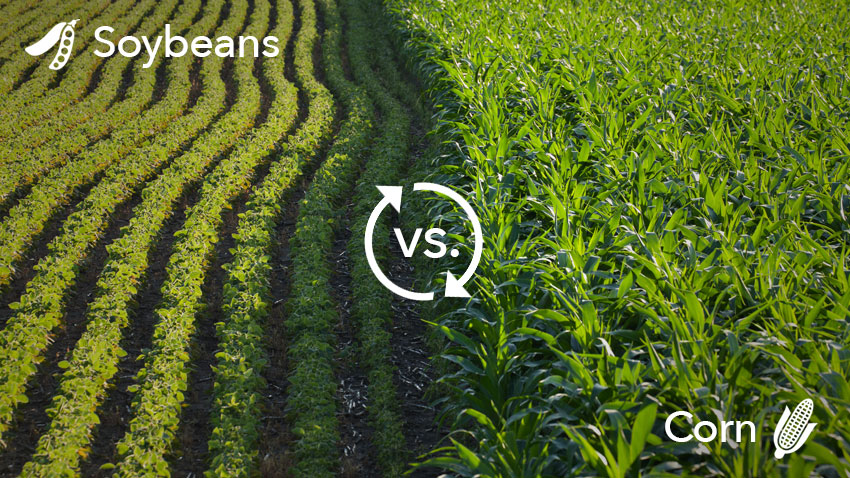

The most popular crop rotation pattern in Illinois because of the yield impacts:

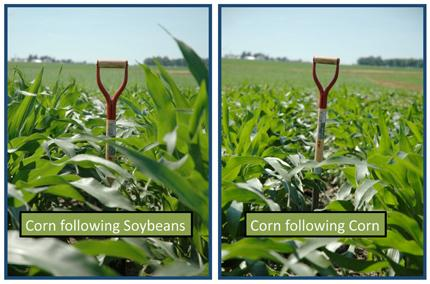

How can we visualize this in the data?

### Steps of the Analysis:
1. Read in shape files + raster files.
2. Clip files.
3. Describe Illinois land uses
4. Create crop rotation rasters.
5. Visualize rasters.
6. Merge in other data sources.

### The Import Line

In [14]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import geopandas
from rasterio.mask import mask
import pandas as pd
import numpy as np
import json
import matplotlib.patches as mpatches
import matplotlib.colors
from scipy.signal import medfilt2d

## 1. Read in Data

Read them in:

In [15]:
data_dir="C:/Users/jhtchns2/Box/ACE_592_SAE/Class_Examples/2_Images/"

Rasters

In [16]:
# CDL from 2017
cdl_17 = rasterio.open(data_dir + "CDL_2017_clip.tif")
# CDL from 2016
cdl_16 = rasterio.open(data_dir + "CDL_2016_clip.tif")

Shapefile

In [17]:
country = geopandas.read_file(data_dir+"us_states.json")

Create a dictionary (just for FUN)

In [18]:
cdls = {16:cdl_16,
        17:cdl_17}

### ahh, but did you remember to check the projection??

In [6]:
cdl_17.crs == country.crs

False

They are not the same! So easiest thing is just to reproject the vector file to the raster's CRS

In [19]:
# Reproject
country = country.to_crs(cdl_16.crs)

## 2. Clipping Files

Want just Continental US

In [20]:
country = country[(country.NAME!="Alaska")&\
                  (country.NAME!="Hawaii")&\
                  (country.NAME!="Puerto Rico")]

<Axes: >

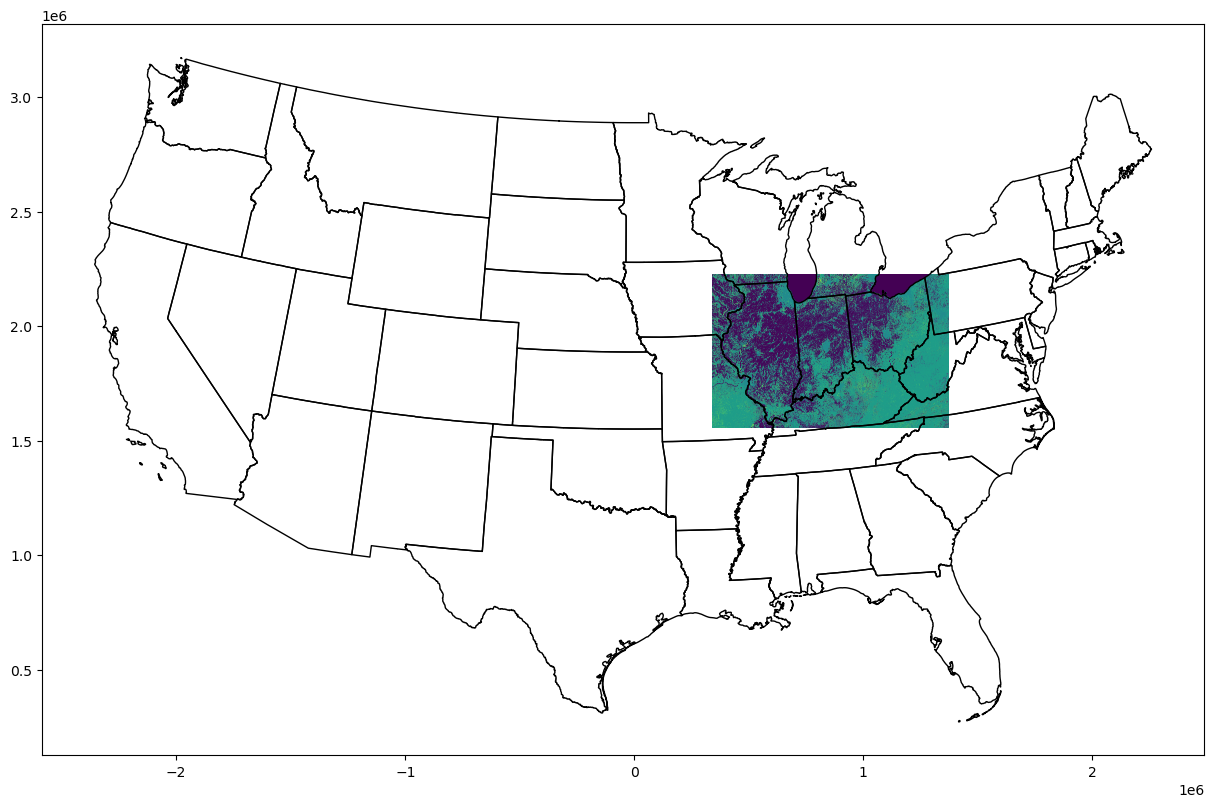

In [9]:
fig, ax = plt.subplots(figsize=(15, 15))
# Plot the CDL from 2016
rasterio.plot.show(cdl_16, ax=ax)
# Plot the country, no facecolor, black edges
country.plot(ax=ax, facecolor='none', edgecolor='black')

So we have a small window over Illinois, Indiana, Kentucky, and Ohio.

We just want Illinois, so we can do some clipping.

In [10]:
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    json_file = json.loads(gdf.to_json())
    return [json_file['features'][0]['geometry']]

In [21]:
# Extract coordinates
IL_coords = getFeatures(country[(country["NAME"] == "Illinois")])
# Mask CDL array with the Illinois shape
img_out, img_transform = mask(cdl_16,IL_coords) 

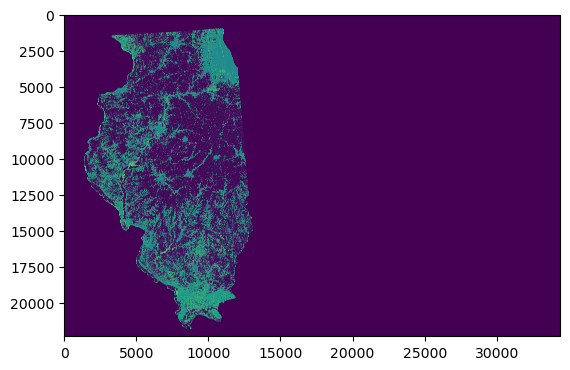

In [12]:
plt.imshow(img_out[0,:,:])

To save space, I'm actually going to cut off the right side of this raster

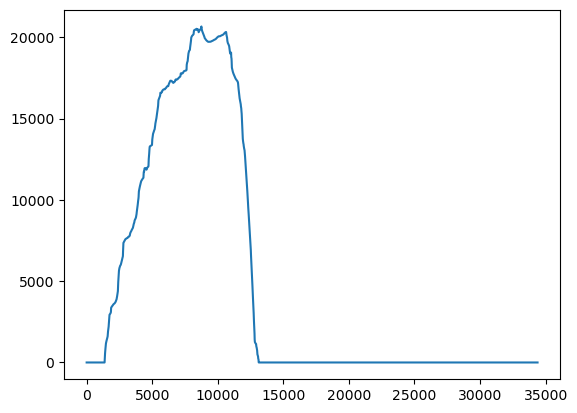

In [13]:
plt.plot((img_out[0,:,:]!=0).sum(axis=0))

The non-zero pixels are basically to the left of 15k.

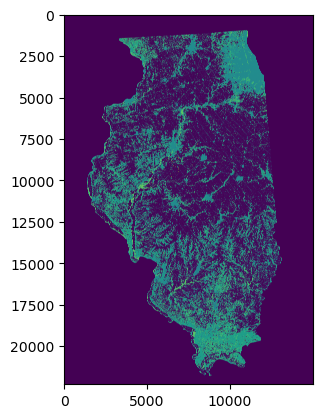

In [14]:
plt.imshow(img_out[0,:,:15000])

Good enough.

There is, however, an easier way to do this... (__Hint: there's an argument I did not use__).

In [22]:
for year,cdl in cdls.items():
    # Transform with the mask
    img_out, img_transform = mask(cdl,IL_coords) 
        
    # Cut out the right side of the image.
    img_out = img_out[:,:,:15000]
        
    # Metadata
    out_meta = cdl.meta.copy()
    out_meta['height'] = img_out.shape[1]
    out_meta['width'] = img_out.shape[2]
    out_meta['transform'] = img_transform
        
    # No data value is 0
    out_meta['nodata'] = 0
    
    # Write to a file, e.g. raster_IL_16.tif
    with rasterio.open("./raster_IL_"+str(year)+".tif", "w", **out_meta) as dest:
        dest.write(img_out)

Now let's see if we did it right

In [23]:
IL_16 = rasterio.open("./raster_IL_16.tif")

<Axes: >

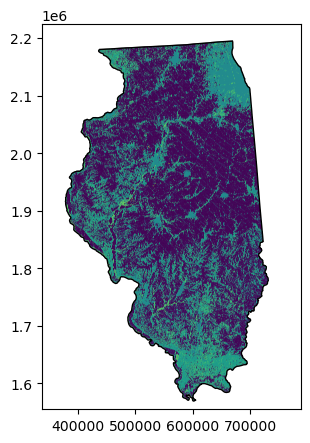

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
rasterio.plot.show(IL_16, ax=ax)
country[country['NAME']=="Illinois"].plot(ax=ax, facecolor='none', edgecolor='black')

Things are missing from the edges because they are zero values, or "background" according to the CDL documentation/

## 3. Top 10 Land Uses in Each Year

To find the names for the pixels, I made a dictionary (json file) from the CDL documentation. In your homework, you will want to create something similar.

In [26]:
pixel_names =\
{1:"Corn", 
5:"Soybeans", 
141:"Deciduous Forest", 
176:"Grassland/Pasture", 
122:"Developed/Low Intensity", 
121:"Developed/Open Space",
111:"Open Water",
123:"Developed/Med Intensity",
190:"Woody Wetlands",
26:"Dbl Crop WinWht/Soybeans"}

Now we store all the rasters in one dictionary:

In [27]:
rasters = {}
for year in cdls.keys():
    rasters[year] = rasterio.open("./raster_IL_"+str(year)+".tif")

Let's look at one example:

In [28]:
# Access the raster at key "17" and read the first band
r17_array = rasters[17].read(1)
# Flatten it, make it a series
pixels = pd.Series(r17_array.flatten())
# Take out all of the zero pixels
pixels = pixels[pixels!=0]
# Call value counts
pixel_counts = pixels.value_counts()
# Look at top 10
pixel_counts.head(10)

1      50384318
5      44901525
141    25540770
176    14179420
122     7641934
121     7299749
111     2901195
123     2686446
190     1864894
26      1293584
Name: count, dtype: int64

But what do these mean?

Here is where the dictionary comes in handy:

In [32]:
# Extract the indices
pixel_ixs = pd.Series(pixel_counts.index)
# Replace the numbers with text labels
pixel_counts.index = pixel_ixs.replace(pixel_names)
# Look at top 10
pixel_counts.head(10)

Corn                        50384318
Soybeans                    44901525
Deciduous Forest            25540770
Grassland/Pasture           14179420
Developed/Low Intensity      7641934
Developed/Open Space         7299749
Open Water                   2901195
Developed/Med Intensity      2686446
Woody Wetlands               1864894
Dbl Crop WinWht/Soybeans     1293584
Name: count, dtype: int64

How much is that? Let's find the percentage.

In [32]:
# Method 1:
# Sum all of the pixels
# Divide the series by the sum, multiply by 100
100*(pixel_counts/pixel_counts.sum()).head(10)

Corn                        31.073817
Soybeans                    27.692379
Deciduous Forest            15.751911
Grassland/Pasture            8.744960
Developed/Low Intensity      4.713065
Developed/Open Space         4.502026
Open Water                   1.789259
Developed/Med Intensity      1.656830
Woody Wetlands               1.150148
Dbl Crop WinWht/Soybeans     0.797800
Name: count, dtype: float64

Had I used the "normalize" argument, I could have done it when I called "value counts"

In [38]:
# Method 2:
# It will automatically divide by the sum
pixel_counts = pixels.value_counts(normalize=True)*100
# Convert to series
pixel_ixs = pd.Series(pixel_counts.index)
# Replace pixel names
pixel_counts.index = pixel_ixs.replace(pixel_names)
# First 10
pixel_counts.head(10)

Corn                        31.073822
Soybeans                    27.692387
Deciduous Forest            15.751912
Grassland/Pasture            8.744959
Developed/Low Intensity      4.713056
Developed/Open Space         4.502018
Open Water                   1.789271
Developed/Med Intensity      1.656828
Woody Wetlands               1.150147
Dbl Crop WinWht/Soybeans     0.797800
Name: proportion, dtype: float64

So 31% of our land mass is corn, 27% soybeans, 15% forest, and the rest other things.

Visualizing with a pie chart is possible, but can be a bit awkward given how many labels there are:

<Axes: ylabel='proportion'>

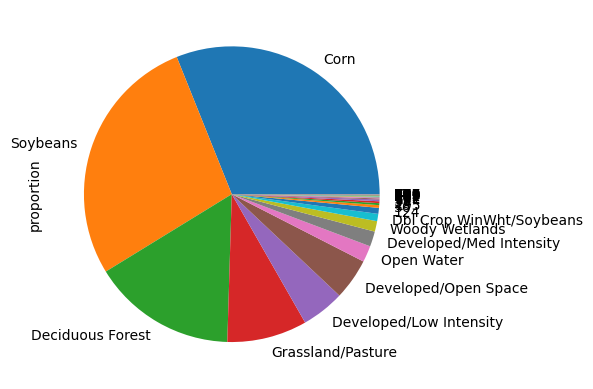

In [39]:
pixel_counts.plot(kind="pie")


Solutions?

Condense some of these categories:

Text(0, 0.5, '')

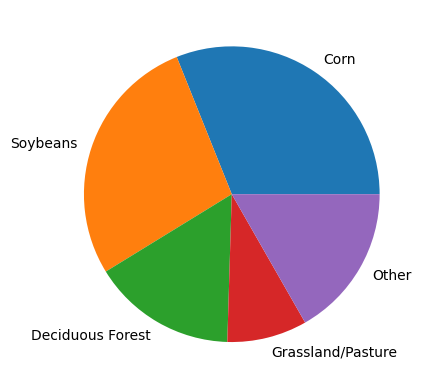

In [41]:
# Take the first four rows
condensed_counts = pixel_counts.iloc[:4]
# Sum everything after that, and call it "Other"
condensed_counts.loc["Other"] = pixel_counts.iloc[4:].sum()
# Plot
condensed_counts.plot(kind="pie")
plt.ylabel("")

We could also try and label things under the "Other" category better:

In [40]:
#             Is "developed" in the string?           each index
Developed = ["Developed" in str(x) for x in list(pixel_counts.index)]
# Reset the index, so that the index is a column
pixel_counts_wix = pixel_counts.reset_index()
# For rows where the index contains "developed", relabel it "Developed"
pixel_counts_wix.loc[Developed,"index"] = "Developed"
# Groupby by the new label, sum, take the column "proportion" and sort
pixel_counts = pixel_counts_wix.groupby("index").sum()['proportion'].sort_values(ascending=False)

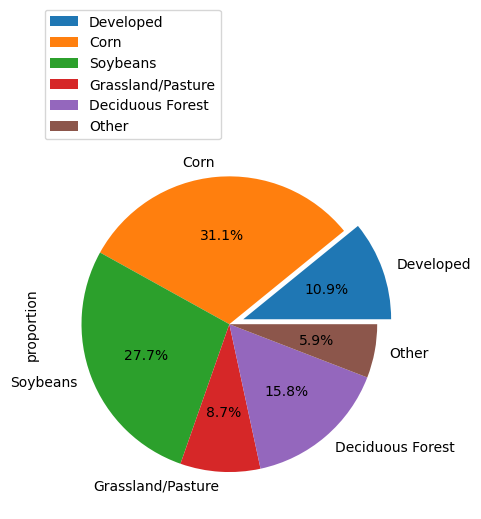

In [45]:
# Only take the first five
condensed_counts = pixel_counts.iloc[:5]
# Assign the rest as "Other"
condensed_counts.loc["Other"] = pixel_counts.iloc[5:].sum()
# Make a new column order
col_order = ["Developed","Corn","Soybeans","Grassland/Pasture","Deciduous Forest","Other"]
# Plot all of these columns in a pie chart
condensed_counts[col_order].plot(kind="pie", # The type of graph
                                 autopct='%1.1f%%', # Show percent
                                 explode=[.1,0,0,0,0,0]) # "explode" the first slice

plt.legend(loc=(0,1))

So above the tables are in units of percentage of land each year.

Mostly just corn, soybeans, and forest.

## 4. Making Crop Rasters

Here I wrote a function that does the write and transform tasks necessary to transform and array into a raster.

In [45]:
def recode_raster_binary(raster,array,img_transform,name):
    # Copy the metadata
    out_meta = raster.meta.copy()
    # Put a "band" axis
    array = array[np.newaxis,:,:]
    # Write in metadata
    out_meta['height'] = array.shape[1]
    out_meta['width'] = array.shape[2]
    out_meta['transform'] = img_transform
    # Write out
    with rasterio.open(name, "w", **out_meta) as dest:
        dest.write(array.astype(rasterio.uint8)) # Notice here it codes "uint8" because thats all we need for binary data

Using the documentation, we know that these are the two codes for corn and soybeans:

In [46]:
crop_labels = {1:"corn",5:"soybeans"}

Below is a nested for loop that creates a nested dictionary with these rasters:

In [47]:
crop_rasters = {}

# For each CDL year:
for year in cdls.keys():
    crop_rasters[year] = {}
        # For each crop:
    for val,crop in crop_labels.items():
            # Read in the band and make a binary array:
        array = (rasters[year].read(1)==val).astype(np.int8)
            
            # Write it out using our function
        recode_raster_binary(cdl,array,img_transform,"./raster_IL_"+str(year)+"_"+crop+".tif")

            # Store it in this dictionary:
        crop_rasters[year][crop] = rasterio.open("./raster_IL_"+str(year)+"_"+crop+".tif")

Now plot it:

In [48]:
# Make some colormaps first:
# Zero = white, One = Blue
cmap_beans = matplotlib.colors.ListedColormap(['white',"C0"])
# Zero = White, One = Dark Green
cmap_corn = matplotlib.colors.ListedColormap(['white',"darkgreen"])

<Axes: title={'center': 'Soybean Area, 2017'}>

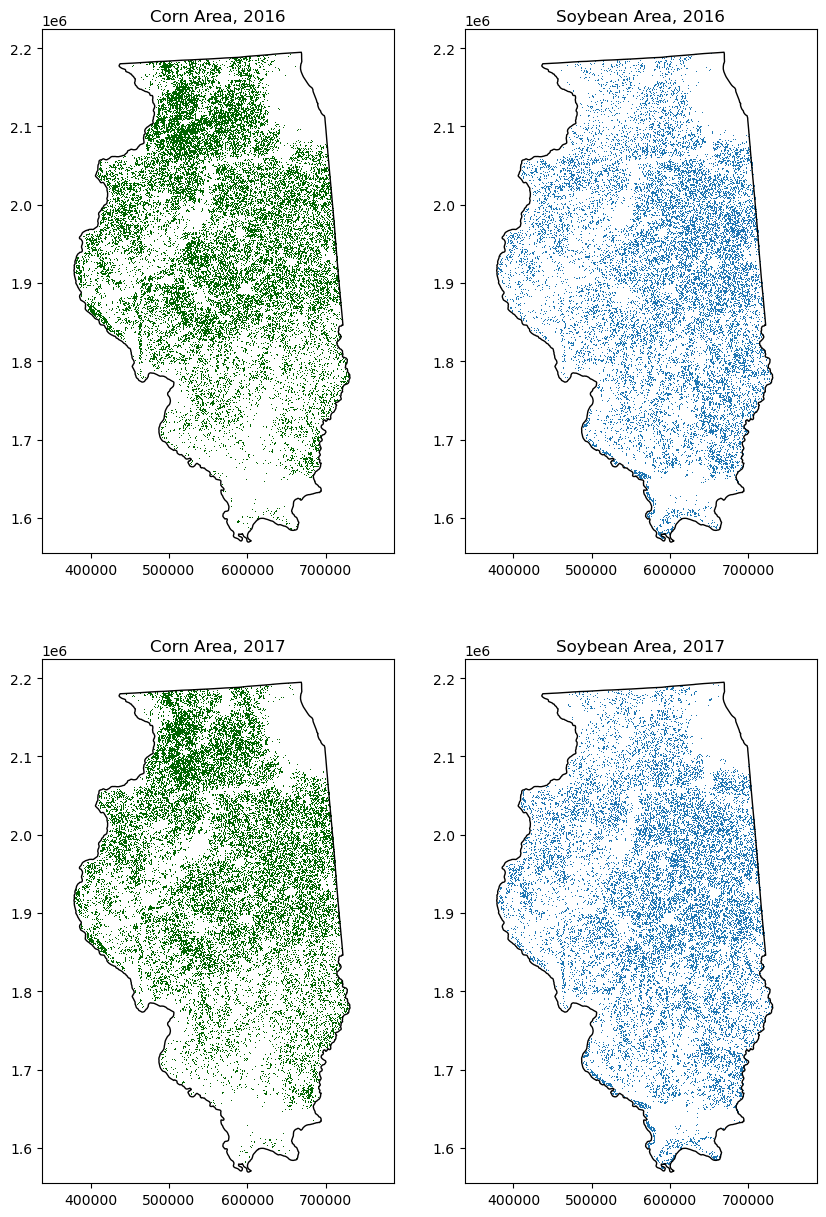

In [50]:
# Make a new axes
fig, ax = plt.subplots(2,2,figsize=(10, 15))

# Corn 2016
rasterio.plot.show(crop_rasters[16]["corn"], ax=ax[0,0],cmap=cmap_corn)
ax[0,0].set_title("Corn Area, 2016")
country[country['NAME']=="Illinois"].plot(ax=ax[0,0], facecolor='none', edgecolor='black')

# Soybeans 2016
rasterio.plot.show(crop_rasters[16]["soybeans"], ax=ax[0,1],cmap=cmap_beans)
ax[0,1].set_title("Soybean Area, 2016")
country[country['NAME']=="Illinois"].plot(ax=ax[0,1], facecolor='none', edgecolor='black')

# Corn 2017
rasterio.plot.show(crop_rasters[17]["corn"], ax=ax[1,0],cmap=cmap_corn)
ax[1,0].set_title("Corn Area, 2017")
country[country['NAME']=="Illinois"].plot(ax=ax[1,0], facecolor='none', edgecolor='black')

# Soybeans 2017
rasterio.plot.show(crop_rasters[17]["soybeans"], ax=ax[1,1],cmap=cmap_beans)
ax[1,1].set_title("Soybean Area, 2017")
country[country['NAME']=="Illinois"].plot(ax=ax[1,1], facecolor='none', edgecolor='black')

### How do we determine crop rotation?

What we want to know is how often a pixel changed from being a 1 to a 5 and vice versa, and also how often did it stay the same.

There are two ways to do this. One is the REALLY LONG way: go through each index and assign a 1 or a 2 to anything monocropped or rotated.

What's the __vectorized__ way?

Since we are comparing pixels in the same location but in different years, we can do an element by element comparison. Is the pixel corn in one year and corn the next? Is the pixel soybeans in one year and corn the next? etc.

In [49]:
# Its very useful to make matrices like this that are three dimensions.
# Each line here reads raster, gives it a new first axis
# The outer code concatenates them on the new first axis to make them 3D arrays.
IL_17 = np.concatenate([rasterio.open("./raster_IL_17_corn.tif").read(1)[np.newaxis,:,:], 
                        rasterio.open("./raster_IL_17_soybeans.tif").read(1)[np.newaxis,:,:]],axis=0) 

IL_16 = np.concatenate([rasterio.open("./raster_IL_16_corn.tif").read(1)[np.newaxis,:,:],
                        rasterio.open("./raster_IL_16_soybeans.tif").read(1)[np.newaxis,:,:]],axis=0)

Here I'm going to assess a boolean condition about the rasters, multiplying them by the number I want them to be.

In [50]:
# Assign a one to anything monocropped
# That pixel in the corn raster stayed one in 2017 and in 2016              
corn_to_corn = ((IL_17[0,:,:]==1)&(IL_16[0,:,:]==1))*1
# That pizel in the soybean raster stayed one in 2017 and in 2016
beans_to_beans = ((IL_17[1,:,:]==1)&(IL_16[1,:,:]==1))*1

# Assign a two to anything that rotated
# If corn raster is 1 in 2017, but soybean raster is equal to 1 in 2016
beans_to_corn = ((IL_17[0,:,:]==1)&(IL_16[1,:,:]==1))*2
# If soybean raster is 1 in 2017, but corn raster is 1 in 2016
corn_to_beans = ((IL_17[1,:,:]==1)&(IL_16[0,:,:]==1))*2

Assuming all these categories are mutually exclusive, we can just add them all together:

In [52]:
Rotated = corn_to_corn + beans_to_beans + beans_to_corn + corn_to_beans

Everything not in those categories will be zero.

So what percent of the pixels were rotated between corn and soybeans?

In [53]:
# Flatten them
rotated_pixels = pd.Series(Rotated.flatten())
# Take out zeros, count values but normalize, multiply by 100
rotated_pixels[rotated_pixels!=0].value_counts(normalize=True)*100

2    78.840058
1    21.159942
Name: proportion, dtype: float64

Nearly 80% of soybeans and corn is rotated between the two.

Visualizing what we just created:

In [54]:
# First put it in a raster format:
recode_raster_binary(cdl_16,Rotated,img_transform,"./raster_IL_rotation.tif")
# Open it again
Rotated_Raster = rasterio.open("./raster_IL_rotation.tif")

Next make a colormap:

In [55]:
labels = {1:"Non-Rotated",
          2:"Rotated"}

# Zero = White, 1 = Red, 2 = Blue
cmap = matplotlib.colors.ListedColormap(['white', "C3","C0"])

# For each of these labels, make me a "patch"
patches =[mpatches.Patch(color=cmap(i),label=labels[i]) \
          for i in labels.keys()]

Now plot them together

(337545.0, 787545.0, 1554765.0, 2223945.0)

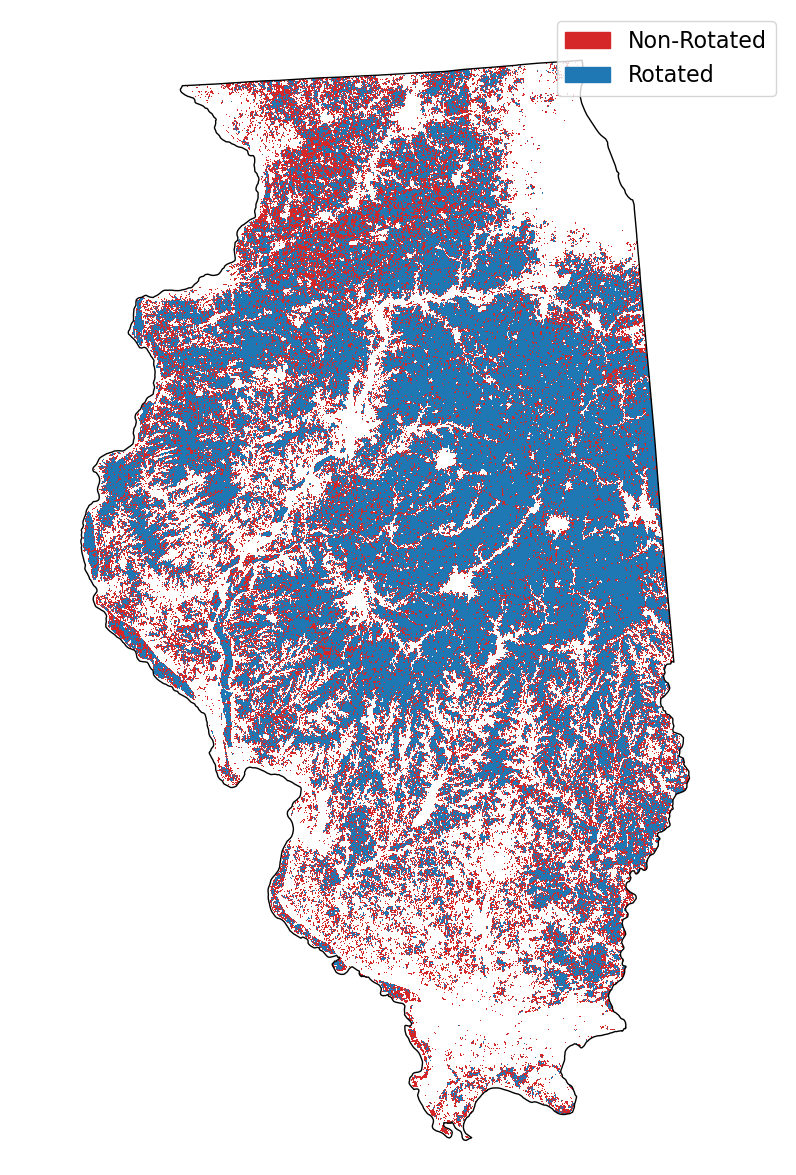

In [59]:
# Make a new axis
fig, ax = plt.subplots(figsize=(15, 15))
# Plot the raster using my colormap
rasterio.plot.show(Rotated_Raster,cmap=cmap,ax=ax)
# Plot the state
country[country['NAME']=="Illinois"].plot(ax=ax, facecolor='none', edgecolor='black')
# Make color patches in the legend
plt.legend(handles=patches,fontsize=16)
# Set the axis off
plt.axis('off')

### What about the different types of rotation?

In [56]:
# As before:
# It's corn in 2017, and corn in 2016
corn_to_corn = ((IL_17[0,:,:]==1)&(IL_16[0,:,:]==1))*1
# It's soybeans in 2017 and soybeans in 2016
beans_to_beans = ((IL_17[1,:,:]==1)&(IL_16[1,:,:]==1))*2
# It's corn in 2017, soybeans in 2016
beans_to_corn = ((IL_17[0,:,:]==1)&(IL_16[1,:,:]==1))*3
# It's soybeans in 2017, corn in 2016
corn_to_beans = ((IL_17[1,:,:]==1)&(IL_16[0,:,:]==1))*4

In [57]:
# Add them all together
Rotated_Cats = corn_to_corn + beans_to_beans + beans_to_corn + corn_to_beans

__FYI: the long, for loop way would be:__

In [ ]:
for i in range(Rotation.shape[0]):
    for j in range(Rotation.shape[1]):
        if (IL_17[0,i,j]==1)&(IL_16[0,i,j]==1):
            Rotation[i,j] = 1
        elif (IL_17[1,i,j]==1)&(IL_16[1,i,j]==1):
            Rotation[i,j] = 2
        elif (IL_17[0,i,j]==1)&(IL_16[1,i,j]==1):
            Rotation[i,j] = 3
        elif (IL_17[1,i,j]==1)&(IL_16[0,i,j]==1):
            Rotation[i,j] = 4

__Don't run this code unless you want your computer to busy for days.__

Writing out the array in a raster format:

In [58]:
# Recode the raster
recode_raster_binary(cdl_16, # original raster
                     Rotated_Cats, # new raster
                     img_transform, # affine transform
                     "./raster_IL_rotation_cats.tif") # name
# Open it again!
Rotated_Cat_Raster = rasterio.open("./raster_IL_rotation_cats.tif")

## 5. Visualizing the Crop Rotation Raster

In [60]:
# Make colormap
cmap = matplotlib.colors.ListedColormap(['white', # 0 (no rotation)
                                         'lightblue', # 1 Corn to corn
                                         'lightcoral', # 2 Beans to beans
                                         "blue", # Beans to corn
                                         "red"]) # Corn to beans
# Make more labels
labels = {1:"Corn to Corn",
          2:"Beans to Beans",
          3:"Beans to Corn",
          4:"Corn to Beans"}
# Make a list of patches for the legend
patches =[mpatches.Patch(color=cmap(i),label=labels[i]) for i in labels.keys()]

(337545.0, 787545.0, 1554765.0, 2223945.0)

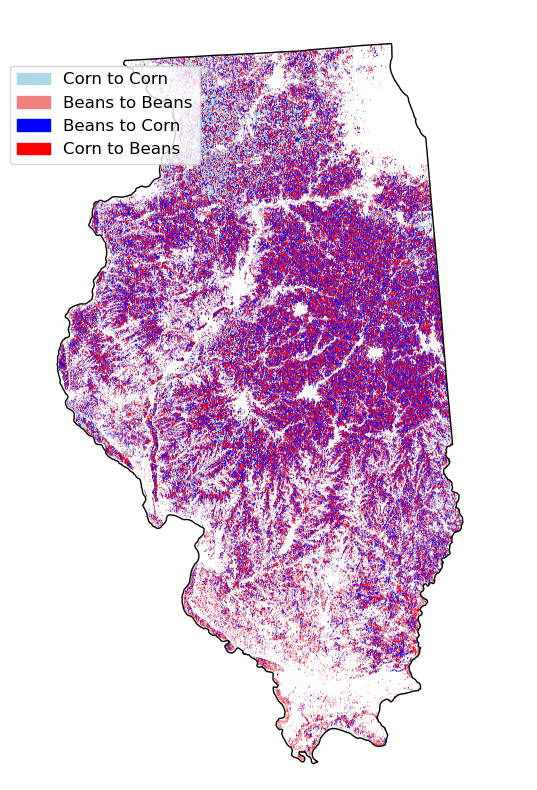

In [61]:
# Plot 
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the new raster
rasterio.plot.show(Rotated_Cat_Raster,cmap=cmap,ax=ax)
# Plot the state
country[country['NAME']=="Illinois"].plot(ax=ax, facecolor='none', edgecolor='black')
# Legend with patches
plt.legend(handles=patches,fontsize=12,loc=(0,.8))
# No axis
plt.axis('off')

In table form:

In [70]:
# Flatten the array
Rotated_Series = pd.Series(Rotated_Cats.flatten())
# Take out zeros, value counts (w normalize), multiply by 100
top_transitions = Rotated_Series[Rotated_Series!=0].value_counts(normalize=True)*100
# Label the pixels
labels = {"1":"Corn to Corn",
          "2":"Beans to Beans",
          "3":"Beans to Corn",
          "4":"Corn to Beans"}
# Replace the numbers with text
top_transitions.index = pd.Series(top_transitions.index).astype(str).replace(labels)
# PRint
top_transitions

Corn to Beans     40.652444
Beans to Corn     38.187612
Corn to Corn      14.326160
Beans to Beans     6.833784
Name: proportion, dtype: float64

Not surprisingly, crop rotation is equally split between corn and beans (nearly). About 20\% of pixels did not rotate, mostly in the North or South of the state.

## 6. Other Data Sources

Suppose we wanted to answer the question "what impact does crop rotation have on crop yield?"

### How might we go about answering this question? 
### Discuss in groups!

Recall that most yield data would be at the county level in our case.